**_#1.数据流的中位数_**

此题的思路时使用最大堆与最小堆存储数据，但因为python只有最小堆，因此采用存储相反数的形式来实现最大堆，取出时记得将数取反即可。
当左右堆大小相等的时候，不要直接向左堆中加入数据，应该先加入到右堆中，然后取出新的右堆的最小值加入到左堆中，因为向左堆中加入数据一共有两种情况，一是加入的数比较小，二是加入的数比较大，而这两种情况可以合并。同理，在左堆比右堆大一的情况下，应先将数据加入到左堆中，才取出左堆中的最大值加入到右堆以满足左堆元素小于右堆元素的性质。
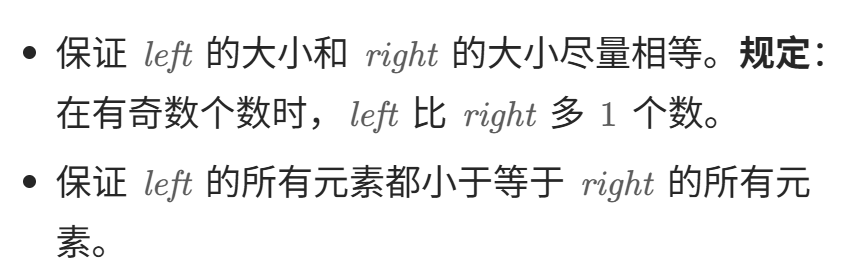

In [1]:
from heapq import heappush, heappushpop


class MedianFinder:

    def __init__(self):
        self.left = [] #最大堆
        self.right = [] #最小堆

    def addNum(self, num: int) -> None:
        if len(self.left) == len(self.right):
            heappush(self.left,-heappushpop(self.right,num))#右堆弹出的元素放在左堆中就是最大的，python只有最小堆，因此取负值后加入左堆就能保证值位于堆顶
        else:
            heappush(self.right,-heappushpop(self.left,-num))#左堆中存储的都是元素的相反数，这样才能实现最大堆的效果，弹出时要进行转换

    def findMedian(self) -> float:
        if len(self.left) == len(self.right):
            return (-self.left[0] + self.right[0]) / 2
        else:
            return -self.left[0]#往最大堆中加入，取出，获取值的时候都要取相反数


# Your MedianFinder object will be instantiated and called as such:
# obj = MedianFinder()
# obj.addNum(num)
# param_2 = obj.findMedian()